Roll No.: 27

Name: Aatif Shaikh

Date of Performance: 9 February 2026

Problem Statement: Design RNN or its variant including LSTM or GRU a) Select a suitable time series dataset.      
Example – predict sentiments based on product reviews b) Apply for prediction

In [1]:
# CELL 1: Import all required libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print(f"TensorFlow version: {tf.__version__}")
print("All libraries imported successfully!")

TensorFlow version: 2.20.0
All libraries imported successfully!


In [3]:
# CELL 3: Load the IMDB dataset
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("=== Dataset Loaded ===")
print(f"Training reviews: {len(X_train)}")   # 25,000
print(f"Testing reviews:  {len(X_test)}")    # 25,000
print(f"Vocabulary size:  {vocab_size} most frequent words")

# Check class distribution
print(f"\nTraining labels distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    label = "Positive" if u == 1 else "Negative"
    print(f"  {label} ({u}): {c} reviews")


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
=== Dataset Loaded ===
Training reviews: 25000
Testing reviews:  25000
Vocabulary size:  10000 most frequent words

Training labels distribution:
  Negative (0): 12500 reviews
  Positive (1): 12500 reviews


=== Sample Review (as integer sequence) ===
First review (first 50 words): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447]
Label: 1 (Positive)

=== Review Length Statistics ===
Shortest review: 11 words
Longest review:  2494 words
Average length:  239 words
Median length:   178 words


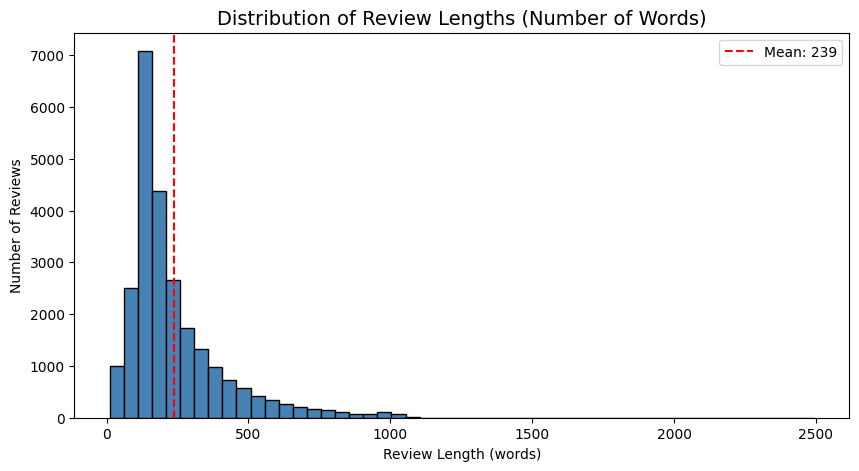


PROBLEM: Reviews have DIFFERENT lengths!
LSTM needs FIXED-LENGTH input → we'll use PADDING in the next step.


In [4]:
# CELL 4: Examine what the data looks like
print("=== Sample Review (as integer sequence) ===")
print(f"First review (first 50 words): {X_train[0][:50]}")
print(f"Label: {y_train[0]} ({'Positive' if y_train[0] == 1 else 'Negative'})")

# Check review lengths — they vary widely!
review_lengths = [len(review) for review in X_train]
print(f"\n=== Review Length Statistics ===")
print(f"Shortest review: {min(review_lengths)} words")
print(f"Longest review:  {max(review_lengths)} words")
print(f"Average length:  {np.mean(review_lengths):.0f} words")
print(f"Median length:   {np.median(review_lengths):.0f} words")

# Visualize the distribution of review lengths
plt.figure(figsize=(10, 5))
plt.hist(review_lengths, bins=50, color='steelblue', edgecolor='black')
plt.axvline(x=np.mean(review_lengths), color='red', linestyle='--',
            label=f'Mean: {np.mean(review_lengths):.0f}')
# axvline draws a vertical line at the mean length
plt.title('Distribution of Review Lengths (Number of Words)', fontsize=14)
plt.xlabel('Review Length (words)')
plt.ylabel('Number of Reviews')
plt.legend()
plt.show()

print("\nPROBLEM: Reviews have DIFFERENT lengths!")
print("LSTM needs FIXED-LENGTH input → we'll use PADDING in the next step.")

In [5]:
# CELL 5: Convert integer sequences back to readable text
# This helps us UNDERSTAND what the model is actually processing

word_index = imdb.get_word_index()

# Create a REVERSE dictionary: {1: "the", 2: "and", 3: "a", ...}
reverse_word_index = {value: key for key, value in word_index.items()}

def decode_review(encoded_review):
    """Convert a sequence of integers back to readable text."""
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])

print("=== First Training Review (decoded to text) ===\n")
print(decode_review(X_train[0]))
print(f"\nLabel: {'POSITIVE ✓' if y_train[0] == 1 else 'NEGATIVE ✗'}")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
=== First Training Review (decoded to text) ===

? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the who

In [6]:
# CELL 6: Pad/truncate all reviews to the same length
maxlen = 200

X_train_padded = pad_sequences(X_train, maxlen=maxlen, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test, maxlen=maxlen, padding='post', truncating='post')
print(f"Before padding:")
print(f"  X_train[0] length: {len(X_train[0])} words")
print(f"  X_train[1] length: {len(X_train[1])} words")

print(f"\nAfter padding:")
print(f"  X_train_padded shape: {X_train_padded.shape}")  # (25000, 200)
print(f"  X_test_padded shape:  {X_test_padded.shape}")   # (25000, 200)
print(f"  Every review is now exactly {maxlen} words long!")

print(f"\nSample padded review (last 20 values):")
print(f"  {X_train_padded[0][-20:]}")

Before padding:
  X_train[0] length: 218 words
  X_train[1] length: 189 words

After padding:
  X_train_padded shape: (25000, 200)
  X_test_padded shape:  (25000, 200)
  Every review is now exactly 200 words long!

Sample padded review (last 20 values):
  [ 134  476   26  480    5  144   30 5535   18   51   36   28  224   92
   25  104    4  226   65   16]


In [7]:
# CELL 7: Define the LSTM neural network architecture
embedding_dim = 128
model = keras.Sequential([

    # ============ LAYER 1: Embedding Layer ============
    layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=maxlen),
    # ============ LAYER 2: LSTM Layer ============
    layers.LSTM(64, return_sequences=False),
    # ============ LAYER 3: Dropout ============
    layers.Dropout(0.5),
    # ============ LAYER 4: Dense Hidden Layer ============
    layers.Dense(32, activation='relu'),
    # ============ LAYER 5: Output Layer ============
    layers.Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# CELL 8: Compile — configure the learning process
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled!")
print("   Optimizer: Adam")
print("   Loss: Binary Crossentropy (for 2-class problems)")
print("   Metric: Accuracy")

✅ Model compiled!
   Optimizer: Adam
   Loss: Binary Crossentropy (for 2-class problems)
   Metric: Accuracy


In [9]:
# CELL 9: Train the LSTM model
history = model.fit(
    X_train_padded, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

print("\n✅ Training complete!")

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 148ms/step - accuracy: 0.5193 - loss: 0.6904 - val_accuracy: 0.5602 - val_loss: 0.6698
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 153ms/step - accuracy: 0.6017 - loss: 0.6386 - val_accuracy: 0.6340 - val_loss: 0.6029
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 147ms/step - accuracy: 0.7182 - loss: 0.5376 - val_accuracy: 0.7840 - val_loss: 0.5369
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 146ms/step - accuracy: 0.6763 - loss: 0.5822 - val_accuracy: 0.6088 - val_loss: 0.6376
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 146ms/step - accuracy: 0.6728 - loss: 0.5720 - val_accuracy: 0.5932 - val_loss: 0.6542

✅ Training complete!


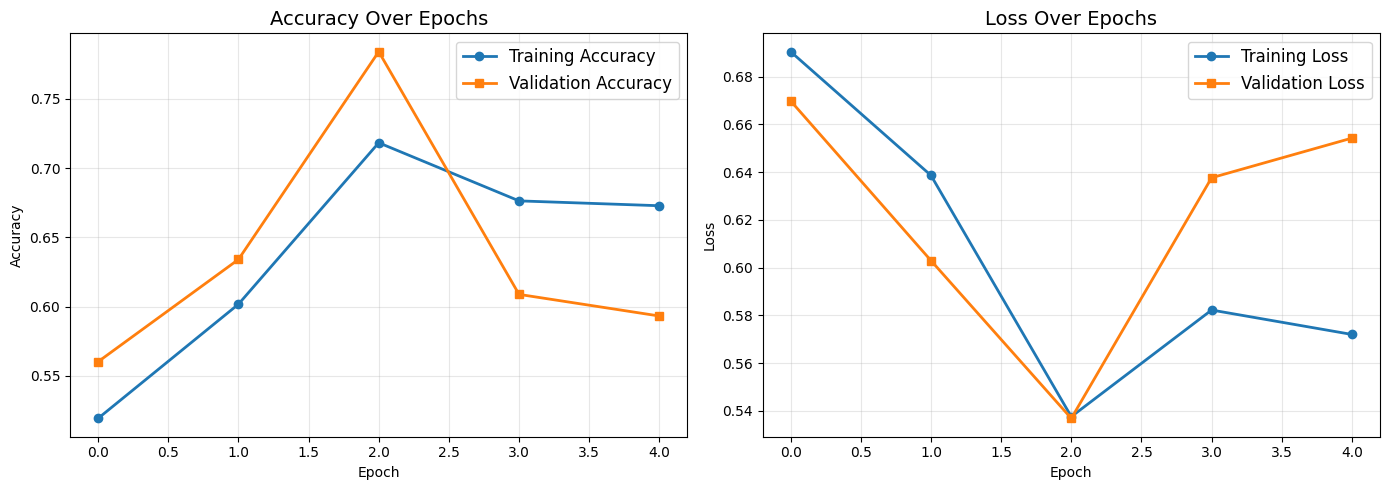

In [10]:
# CELL 10: Visualize how training progressed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Accuracy Plot ---
axes[0].plot(history.history['accuracy'], label='Training Accuracy',
             linewidth=2, marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy',
             linewidth=2, marker='s')
# marker='o' and 's' add circle and square markers at each epoch point
axes[0].set_title('Accuracy Over Epochs', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# --- Loss Plot ---
axes[1].plot(history.history['loss'], label='Training Loss',
             linewidth=2, marker='o')
axes[1].plot(history.history['val_loss'], label='Validation Loss',
             linewidth=2, marker='s')
axes[1].set_title('Loss Over Epochs', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# WHAT TO LOOK FOR:
# ✓ Both lines going up/down together → model is learning well
# ✗ Training accuracy high but validation accuracy low → OVERFITTING
# ✗ Both lines flat → model is NOT learning (increase epochs or model size)

In [11]:
# CELL 11: Test the model on completely unseen reviews
test_loss, test_accuracy = model.evaluate(X_test_padded, y_test, verbose=0)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"\n→ The LSTM correctly predicts sentiment for {test_accuracy*100:.2f}% of unseen reviews!")

Test Loss:     0.6660
Test Accuracy: 0.5779 (57.79%)

→ The LSTM correctly predicts sentiment for 57.79% of unseen reviews!


782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step


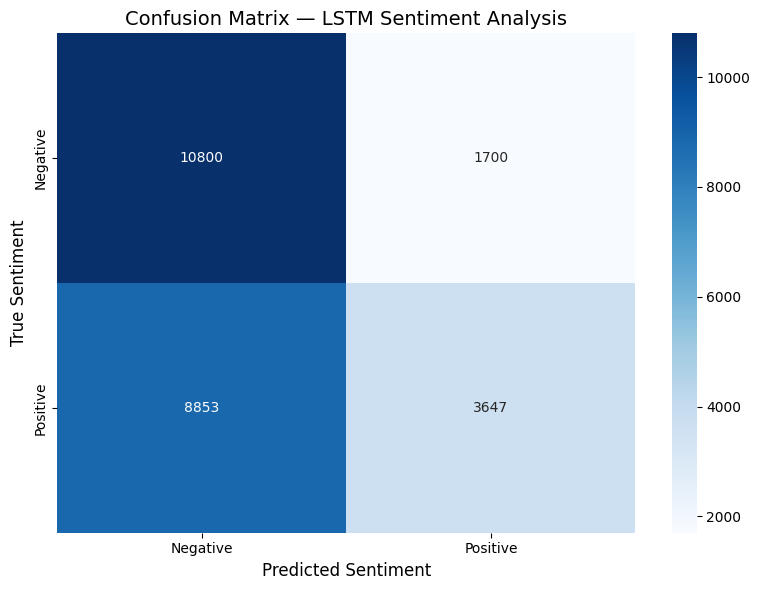


True Negatives:  10800 (correctly identified negative reviews)
False Positives: 1700 (negative reviews wrongly called positive)
False Negatives: 8853 (positive reviews wrongly called negative)
True Positives:  3647 (correctly identified positive reviews)


In [12]:
# CELL 12: Generate predictions and confusion matrix
y_pred_probs = model.predict(X_test_padded)
y_pred_classes = (y_pred_probs > 0.5).astype(int).flatten()
# Build confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.title('Confusion Matrix — LSTM Sentiment Analysis', fontsize=14)
plt.xlabel('Predicted Sentiment', fontsize=12)
plt.ylabel('True Sentiment', fontsize=12)
plt.tight_layout()
plt.show()

# Print the four values explicitly
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives:  {tn} (correctly identified negative reviews)")
print(f"False Positives: {fp} (negative reviews wrongly called positive)")
print(f"False Negatives: {fn} (positive reviews wrongly called negative)")
print(f"True Positives:  {tp} (correctly identified positive reviews)")

In [13]:
# CELL 13: Detailed precision, recall, F1-score per class
print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_test, y_pred_classes,
                            target_names=['Negative', 'Positive']))
# PRECISION: Of all reviews predicted as Positive, how many actually are?
# RECALL:    Of all truly Positive reviews, how many did we catch?
# F1-SCORE:  Harmonic mean of precision and recall
# SUPPORT:   Number of actual reviews in each class

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.55      0.86      0.67     12500
    Positive       0.68      0.29      0.41     12500

    accuracy                           0.58     25000
   macro avg       0.62      0.58      0.54     25000
weighted avg       0.62      0.58      0.54     25000



In [14]:
# CELL 14: Test the model on your OWN custom reviews!

def predict_sentiment(review_text):
    """Takes a plain English review and predicts its sentiment."""

    # Step 1: Convert words to integers using the same word_index
    word_index = imdb.get_word_index()
    encoded = [word_index.get(word.lower(), 2) + 3 for word in review_text.split()]
    # Step 2: Pad to the same length (200) used during training
    padded = pad_sequences([encoded], maxlen=maxlen, padding='post', truncating='post')

    # Step 3: Predict
    prediction = model.predict(padded, verbose=0)[0][0]

    # Step 4: Display result
    sentiment = "POSITIVE 😊" if prediction > 0.5 else "NEGATIVE 😞"
    confidence = prediction if prediction > 0.5 else (1 - prediction)
    print(f"Review:     \"{review_text}\"")
    print(f"Prediction: {sentiment}")
    print(f"Confidence: {confidence*100:.1f}%")
    print(f"Raw Score:  {prediction:.4f} (>0.5 = positive, <0.5 = negative)")
    print("-" * 60)

# Test with different reviews
print("=" * 60)
print("CUSTOM REVIEW PREDICTIONS")
print("=" * 60)

predict_sentiment("This movie was absolutely amazing and I loved every minute of it")
predict_sentiment("Terrible film worst acting I have ever seen complete waste of time")
predict_sentiment("The movie was okay nothing special but not bad either")
predict_sentiment("Brilliant performances outstanding direction a true masterpiece")
predict_sentiment("I fell asleep during this boring and dull movie")

CUSTOM REVIEW PREDICTIONS
Review:     "This movie was absolutely amazing and I loved every minute of it"
Prediction: NEGATIVE 😞
Confidence: 50.6%
Raw Score:  0.4941 (>0.5 = positive, <0.5 = negative)
------------------------------------------------------------
Review:     "Terrible film worst acting I have ever seen complete waste of time"
Prediction: NEGATIVE 😞
Confidence: 50.6%
Raw Score:  0.4941 (>0.5 = positive, <0.5 = negative)
------------------------------------------------------------
Review:     "The movie was okay nothing special but not bad either"
Prediction: NEGATIVE 😞
Confidence: 50.6%
Raw Score:  0.4941 (>0.5 = positive, <0.5 = negative)
------------------------------------------------------------
Review:     "Brilliant performances outstanding direction a true masterpiece"
Prediction: POSITIVE 😊
Confidence: 83.4%
Raw Score:  0.8341 (>0.5 = positive, <0.5 = negative)
------------------------------------------------------------
Review:     "I fell asleep during this borin

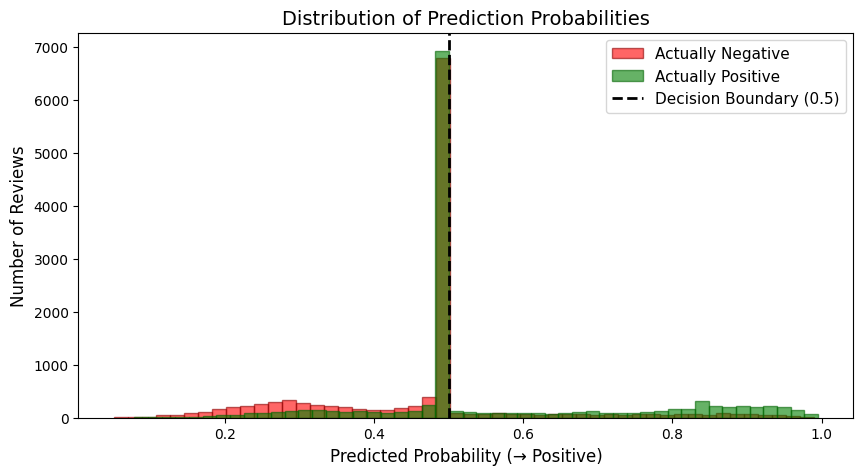

In [15]:
# CELL 15: Distribution of prediction probabilities
plt.figure(figsize=(10, 5))

# Separate predictions by actual class
neg_preds = y_pred_probs[y_test == 0]  # Predictions for actually negative reviews
pos_preds = y_pred_probs[y_test == 1]  # Predictions for actually positive reviews

plt.hist(neg_preds, bins=50, alpha=0.6, color='red', label='Actually Negative', edgecolor='darkred')
plt.hist(pos_preds, bins=50, alpha=0.6, color='green', label='Actually Positive', edgecolor='darkgreen')

plt.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Boundary (0.5)')

plt.title('Distribution of Prediction Probabilities', fontsize=14)
plt.xlabel('Predicted Probability (→ Positive)', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.legend(fontsize=11)
plt.show()

# IDEAL: Red bars clustered near 0 (left), Green bars clustered near 1 (right)
# with minimal overlap around 0.5

In [16]:
# CELL 16: BONUS — Build a GRU model (simpler alternative to LSTM)
# GRU = Gated Recurrent Unit — a lighter version of LSTM

gru_model = keras.Sequential([
    layers.Embedding(vocab_size, embedding_dim, input_length=maxlen),

    layers.GRU(64, return_sequences=False),
    layers.Dropout(0.5),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("GRU Model Architecture:")
gru_model.summary()

# Train the GRU model
print("\n--- Training GRU Model ---")
gru_history = gru_model.fit(
    X_train_padded, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Evaluate
gru_loss, gru_acc = gru_model.evaluate(X_test_padded, y_test, verbose=0)
print(f"\nGRU Test Accuracy: {gru_acc:.4f} ({gru_acc*100:.2f}%)")
print(f"LSTM Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"\nDifference: {abs(gru_acc - test_accuracy)*100:.2f}% — they perform similarly!")

GRU Model Architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


--- Training GRU Model ---
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 159ms/step - accuracy: 0.5083 - loss: 0.6931 - val_accuracy: 0.5234 - val_loss: 0.6895
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 156ms/step - accuracy: 0.5858 - loss: 0.6568 - val_accuracy: 0.5840 - val_loss: 0.6514
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 155ms/step - accuracy: 0.8149 - loss: 0.4128 - val_accuracy: 0.8274 - val_loss: 0.3973
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 155ms/step - accuracy: 0.9214 - loss: 0.2178 - val_accuracy: 0.8634 - val_loss: 0.3596
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 158ms/step - accuracy: 0.9604 - loss: 0.1283 - val_accuracy: 0.8596 - val_loss: 0.4194

GRU Test Accuracy: 0.8417 (84.17%)
LSTM Test Accuracy: 0.5779 (57.79%)

Difference: 26.38% — they perform similarly!
